In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/california-housing-prices/housing.csv


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
data = pd.read_csv("/kaggle/input/california-housing-prices/housing.csv")

In [4]:
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [6]:
data.dropna(inplace=True)

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.7+ MB


In [8]:
Z = data.drop(['median_house_value', 'ocean_proximity'], axis=1)

In [9]:
show_data = Z

In [10]:
from sklearn.model_selection import train_test_split

X = data.drop(['median_house_value'], axis=1)
y = data['median_house_value']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [12]:
train_data = X_train.join(y_train)

In [13]:
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
15834,-122.44,37.75,52.0,2082.0,425.0,801.0,411.0,4.2708,NEAR BAY,368900.0
7423,-118.21,33.96,43.0,1686.0,446.0,1590.0,474.0,2.3241,<1H OCEAN,159300.0
11812,-121.15,39.00,15.0,4145.0,691.0,1872.0,680.0,4.3553,INLAND,220600.0
6444,-118.03,34.11,38.0,2076.0,361.0,988.0,332.0,5.9175,INLAND,416900.0
20256,-119.17,34.21,33.0,1039.0,256.0,1432.0,272.0,3.1103,NEAR OCEAN,143500.0
...,...,...,...,...,...,...,...,...,...,...
15820,-122.42,37.75,52.0,1855.0,611.0,1715.0,614.0,2.1289,NEAR BAY,250000.0
12535,-121.51,38.56,43.0,1048.0,312.0,1320.0,294.0,1.0649,INLAND,137500.0
12290,-116.97,33.94,29.0,3197.0,632.0,1722.0,603.0,3.0432,INLAND,91200.0
17101,-122.23,37.46,36.0,6090.0,1057.0,3081.0,1075.0,5.6629,NEAR OCEAN,343600.0


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

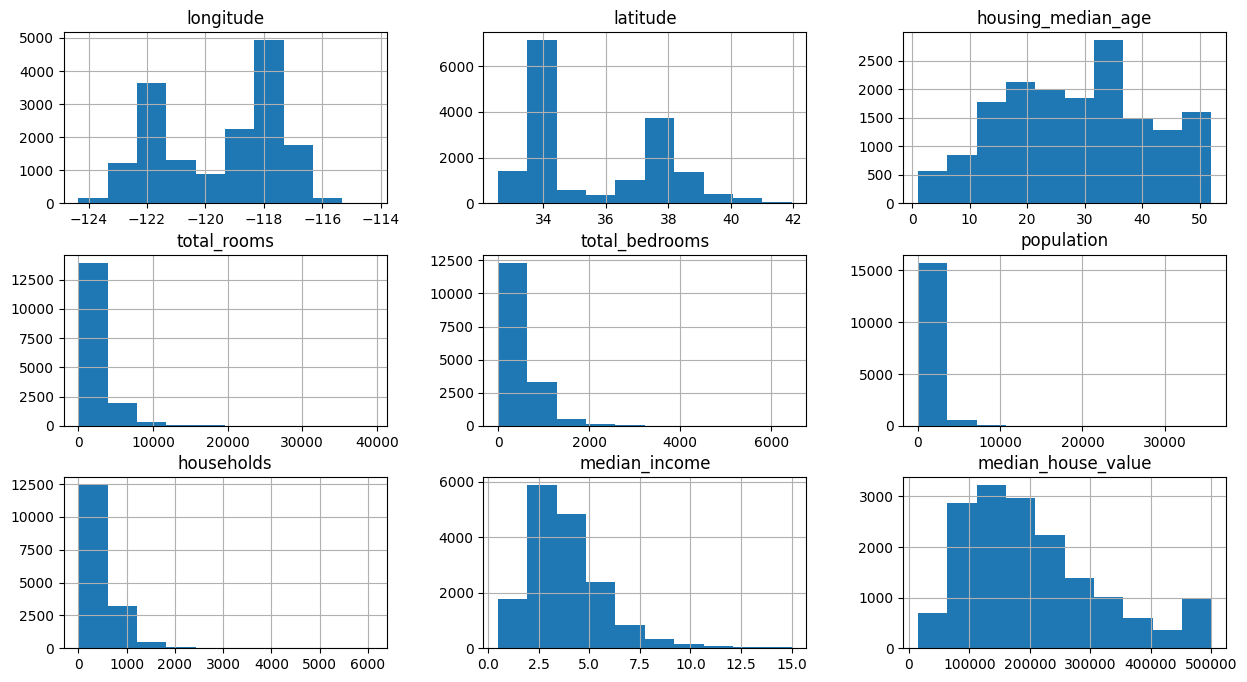

In [14]:
train_data.hist(figsize=(15, 8))

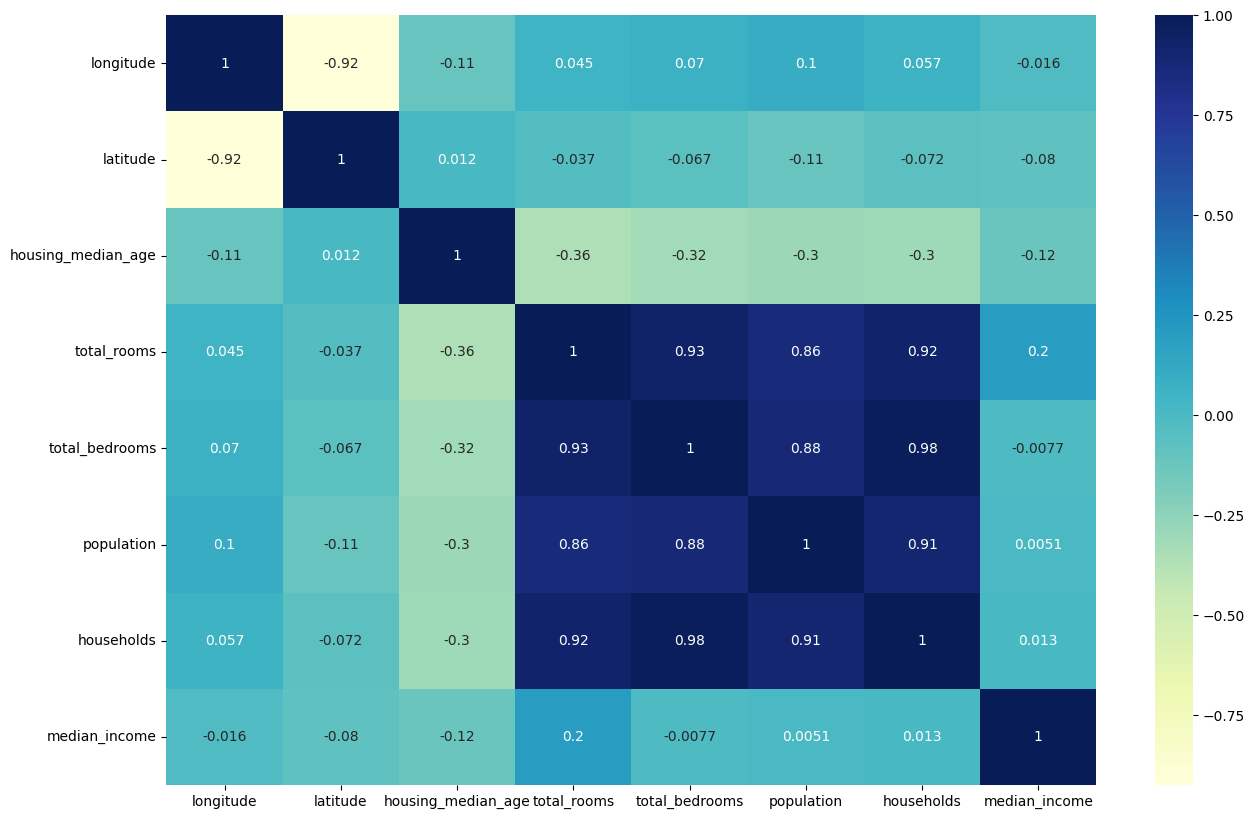

In [15]:
plt.figure(figsize=(15, 10))  # Set the figure size
sns.heatmap(show_data.corr(), annot=True, cmap="YlGnBu")
plt.show()

In [16]:
train_data['total_rooms'] = np.log(train_data['total_rooms'] + 1)
train_data['households'] = np.log(train_data['households'] + 1)
train_data['total_bedrooms'] = np.log(train_data['total_bedrooms'] + 1)
train_data['population'] = np.log(train_data['population'] + 1)

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

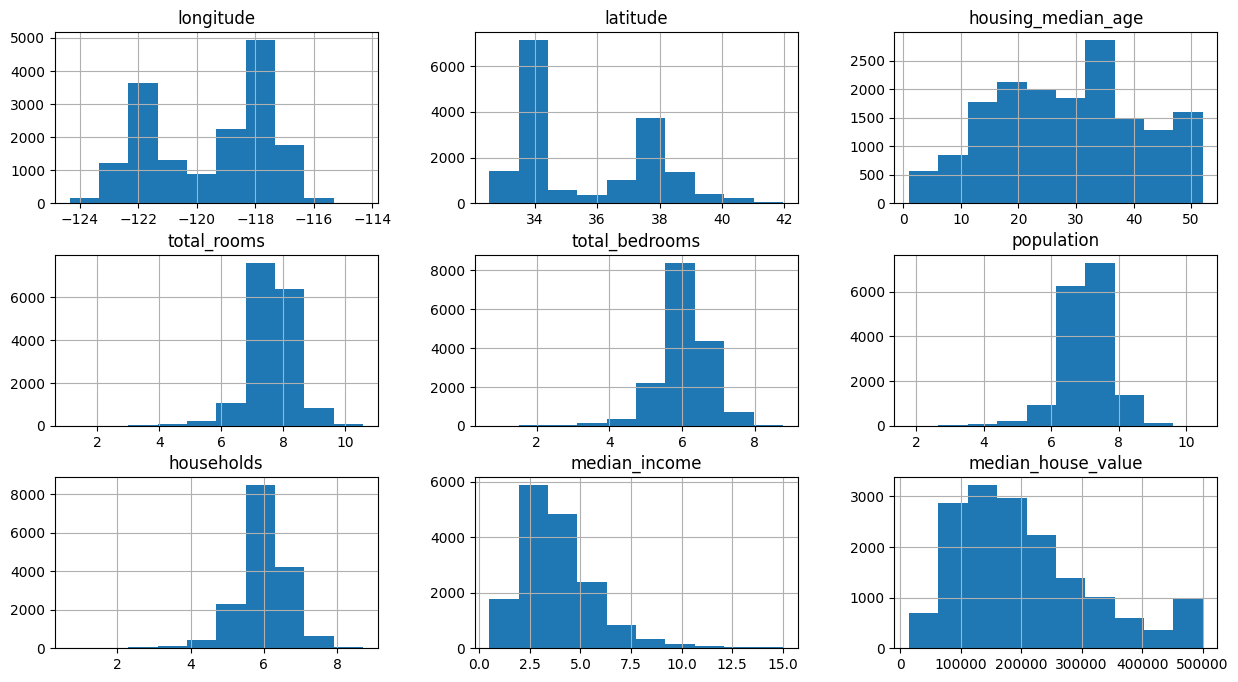

In [17]:
train_data.hist(figsize=(15, 8))

In [18]:
train_data.head

<bound method NDFrame.head of        longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
15834    -122.44     37.75                52.0     7.641564        6.054439   
7423     -118.21     33.96                43.0     7.430707        6.102559   
11812    -121.15     39.00                15.0     8.329899        6.539586   
6444     -118.03     34.11                38.0     7.638680        5.891644   
20256    -119.17     34.21                33.0     6.946976        5.549076   
...          ...       ...                 ...          ...             ...   
15820    -122.42     37.75                52.0     7.526179        6.416732   
12535    -121.51     38.56                43.0     6.955593        5.746203   
12290    -116.97     33.94                29.0     8.070281        6.450470   
17101    -122.23     37.46                36.0     8.714568        6.964136   
9881     -121.80     36.68                18.0     9.057422        7.579679   

       population  ho

In [19]:
train_data = train_data.join(pd.get_dummies((train_data.ocean_proximity), dtype=int))


In [20]:
train_data = train_data.drop('ocean_proximity', axis=1)

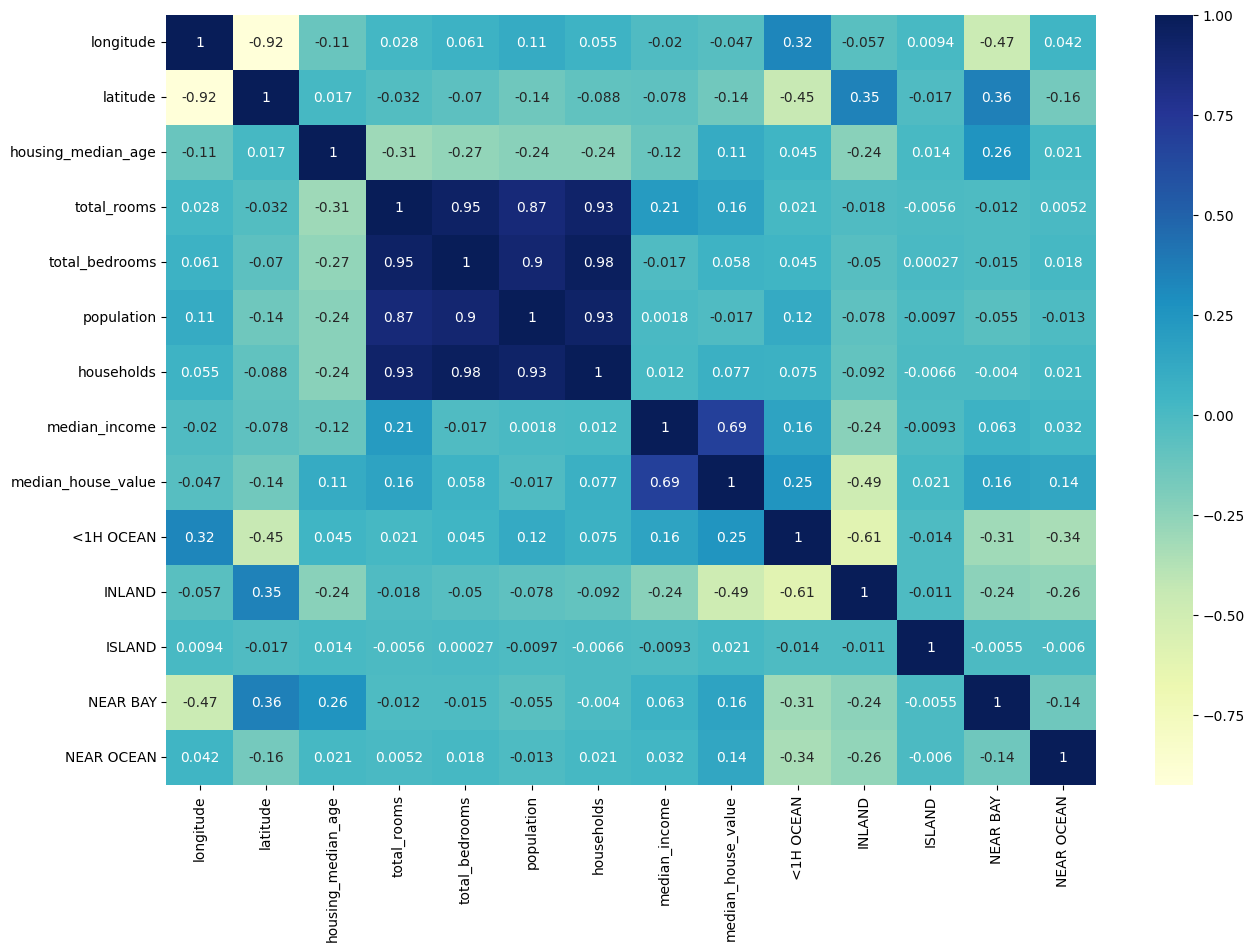

In [21]:
plt.figure(figsize=(15, 10))  # Set the figure size
sns.heatmap(train_data.corr(), annot=True, cmap="YlGnBu")
plt.show()

<Axes: xlabel='latitude', ylabel='longitude'>

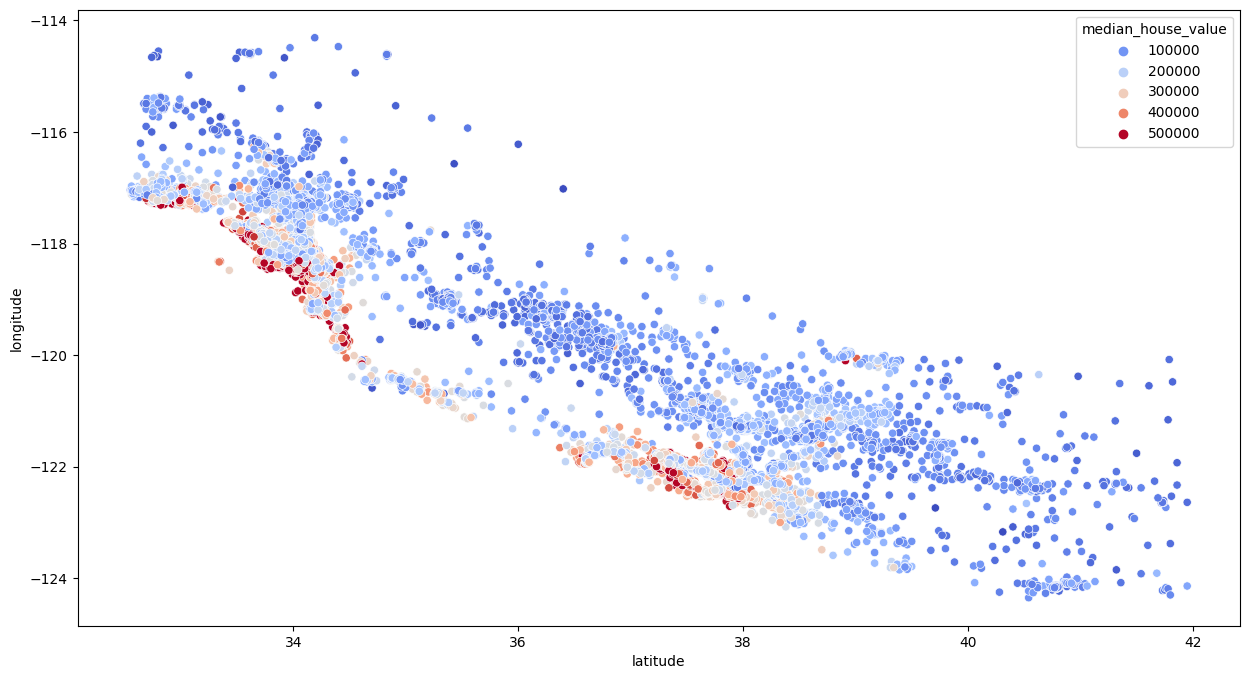

In [25]:
plt.figure(figsize=(15, 8))
sns.scatterplot(x="latitude", y="longitude", data=train_data, hue="median_house_value", palette="coolwarm")

In [27]:
train_data['bedroom_ratio'] = train_data['total_bedrooms'] / train_data['total_rooms']
train_data['households_rooms'] = train_data['total_rooms'] / train_data['households']

<Axes: >

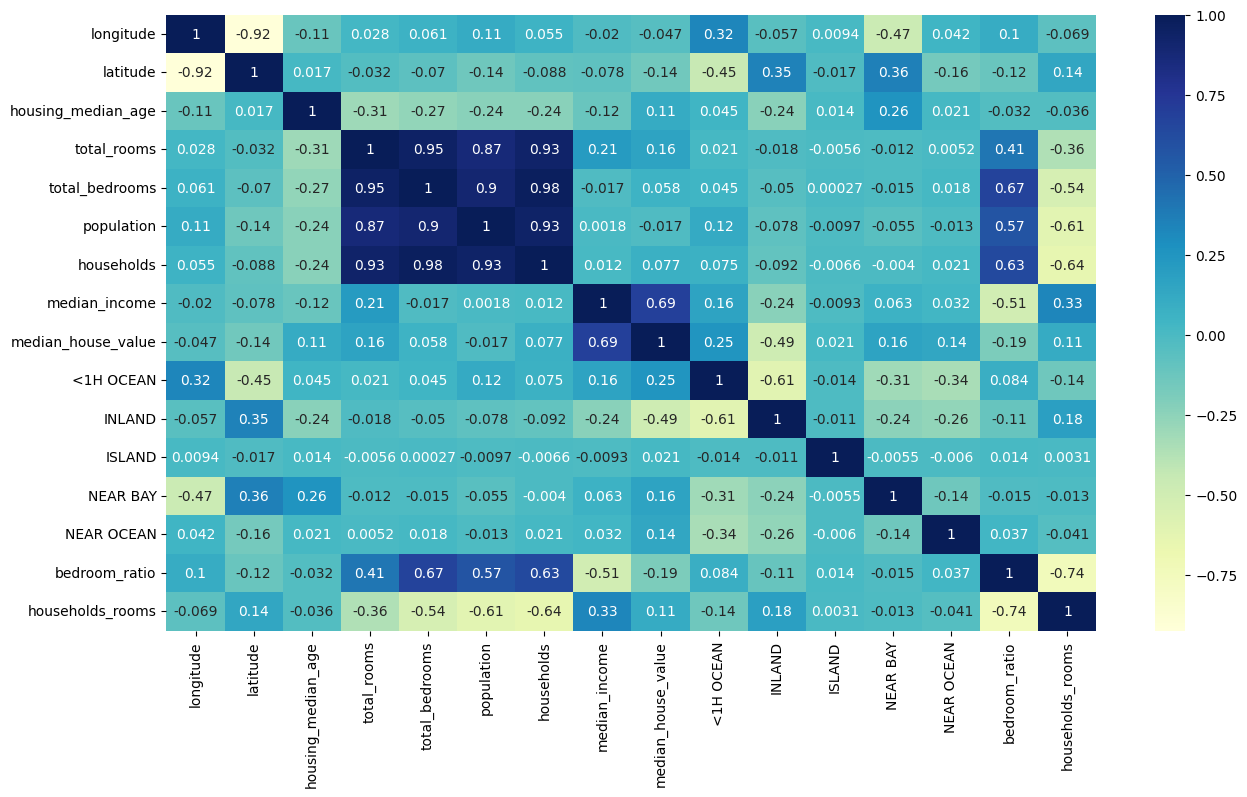

In [28]:
plt.figure(figsize=(15, 8))
sns.heatmap(train_data.corr(), annot=True, cmap="YlGnBu")

In [39]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train, y_train = train_data.drop(['median_house_value'], axis=1), train_data['median_house_value']
X_train_s = scaler.fit_transform(X_train)

reg = LinearRegression()

reg.fit(X_train_s, y_train)

LinearRegression()

In [34]:
test_data = X_test.join(y_test)

test_data['total_rooms'] = np.log(test_data['total_rooms'] + 1)
test_data['households'] = np.log(test_data['households'] + 1)
test_data['total_bedrooms'] = np.log(test_data['total_bedrooms'] + 1)
test_data['population'] = np.log(test_data['population'] + 1)

test_data = test_data.join(pd.get_dummies((test_data.ocean_proximity), dtype=int))
test_data = test_data.drop('ocean_proximity', axis=1)

test_data['bedroom_ratio'] = test_data['total_bedrooms'] / test_data['total_rooms']
test_data['households_rooms'] = test_data['total_rooms'] / test_data['households']

X_test, y_test = test_data.drop(['median_house_value'], axis=1), test_data['median_house_value']

In [40]:
X_test_s = scaler.transform(X_test)

In [41]:
reg.score(X_test_s, y_test)

0.6710332590109342

In [44]:
from sklearn.ensemble import RandomForestRegressor

forest = RandomForestRegressor()

forest.fit(X_train_s, y_train)

RandomForestRegressor()

In [45]:
forest.score(X_test_s, y_test)

0.8240057382432351

In [58]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [30, 60, 90, 120],
    "max_features": [8, 16, 24],
    "min_samples_split": [2, 4],
    "max_depth": [None, 4, 8]
}

grid_search = GridSearchCV(forest, param_grid, cv=5,
                          scoring="neg_mean_squared_error",
                          return_train_score=True)
grid_search.fit(X_train_s, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(),
             param_grid={'max_depth': [None, 4, 8], 'max_features': [8, 16, 24],
                         'min_samples_split': [2, 4],
                         'n_estimators': [30, 60, 90, 120]},
             return_train_score=True, scoring='neg_mean_squared_error')

In [59]:
grid_search.best_estimator_

RandomForestRegressor(max_features=8, n_estimators=120)

In [62]:
grid_search.best_estimator_.score(X_test_s, y_test)

0.8267456524080832